<a href="https://colab.research.google.com/github/aryashivakumar/dataScience/blob/main/Unit8/AryaKumarUnit8ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 8 Exercises: The Art of BART

These exercises are grouped into two parts:

- Questions on the nature of decision trees, random forests, and BART models
- An oppurtunity to practice implementing and analyzing a BART model.

Enjoy!

## Bartian Theory

**Task1**:

Draw a decision tree--on a physical piece of paper--that predicts how many calories you burn in a day, using time you spent exercising that day (in minutes) as a predictor.

To help you understand what you're doing with this tree, seperately create an x/y plot with time exercising as x, and calories burned as y.

If this seems to easy, then add another variable or two (type of exercise?), and/or increase the depth of your tree.

You do not have to show me or turn in your tree to earn credit for this question, although I would like to see your drawing.

**Task2**:

What is a decision tree? How do they work?

A decision tree is a binary list of options that can be chosen between one or the other, this helps with determining all possible options that can occur in a given situation Each layer essentially sorts through the predictors into subsets

**Task3**:

What does the "depth" of a decision tree mean?

How do I know if a tree is too deep, or not deep enough?

The depth of a decision tree refers to the amount of layers, this helps determine how well it fits the data, if a tree is too deep this can easily lead to overfitting or noise in the data, if its not deep enough this could cause underfitting and lead to no capture of pattern in the data.

**Task4:**

How are BART models similar and different from a decision tree?

Bart models are similar to decision trees as they use multiple decision trees to promote a variety of results, bart then alters or changes the trees based on other trees in order to ensure they are all different. This is done to limit overfitting.

**Task5**:

Why would we use a BART model instead of a decision tree?

To mitigate overfitting while still getting the benefits of a deicison tree?

## Bartian Penguins

**Task6**:

Create a BART model that uses flipper length, bill depth, and bill length to predict body mass in penguins, and make a ppc to check its fit

Code for loading the data is below. You'll need to do everything else yourself.

Remember to use my notes as a reference, and to copy and paste from them when it makes sense to.

Oh, and try a normal likelihood.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import graphviz as gv


In [2]:
!pip install pymc-bart
import pymc_bart as pmb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.4 MB/s eta 0:00:00


In [3]:
#drop the incomplete rows from the data
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url).dropna()
penguins.head()

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.25,female,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.45,female,2007
5,Adelie,Torgersen,3.93,2.06,19.0,3.65,male,2007


In [4]:
clmn_list = ['species', 'island', 'bill_length', 'bill_depth', 'bill_depth', 'flipper_length', 'body_mass', 'sex', 'year']
penguinsigma =  penguins.loc[:,clmn_list].dropna()
penguinsigma.head()


,species,island,bill_length,bill_depth,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,1.87,18.1,3.75,male,2007
1,Adelie,Torgersen,3.95,1.74,1.74,18.6,3.80,female,2007
2,Adelie,Torgersen,4.03,1.80,1.80,19.5,3.25,female,2007
4,Adelie,Torgersen,3.67,1.93,1.93,19.3,3.45,female,2007
5,Adelie,Torgersen,3.93,2.06,2.06,19.0,3.65,male,2007


In [5]:
X = penguinsigma[['flipper_length', 'bill_depth', 'bill_length']]
Y = penguinsigma['body_mass']

In [6]:
with pm.Model() as model_penguin:
    s = pm.HalfNormal('s',20) #sigma = 20 is a blind guess
    μ_ = pmb.BART("μ_", X, np.log(Y), m=50) #log around Y
    μ = pm.Deterministic("μ",pm.math.exp(μ_)) #exp it all once BART is done
    y = pm.Gamma("y", mu=μ, sigma=s,  observed=Y) #likelihood
    idata_ps = pm.sample(compute_convergence_checks=False)

Output()

In [7]:
pm.sample_posterior_predictive(idata_ps, model_penguin, extend_inferencedata=True)

Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

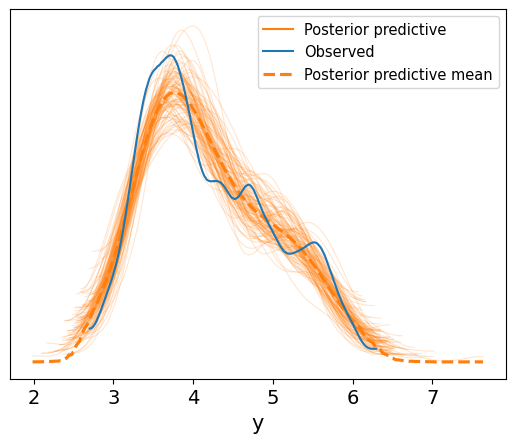

In [8]:
ax = az.plot_ppc(idata_ps, num_pp_samples=100, colors=["C1", "C0", "C1"])

**Task7**:

Plot flipper length versus body mass,

and then plot the posterior predictve from the model over the data.
You're going to copy paste the plotting code from the notes, fyi.

<Axes: xlabel='flipper_length', ylabel='body_mass'>

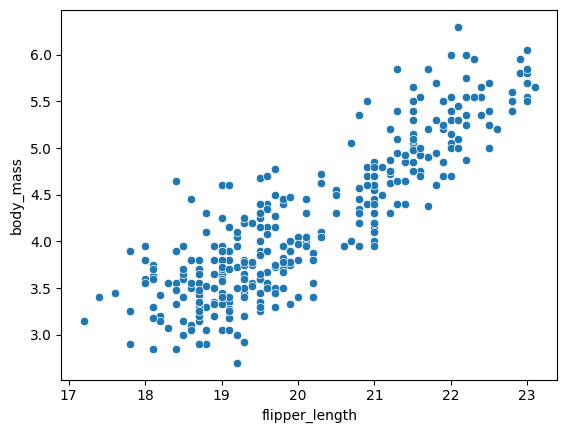

In [9]:
sns.scatterplot(data = penguinsigma, y = 'body_mass', x = 'flipper_length')

In [10]:
posterior_mean = idata_ps.posterior["μ"]

μ_hdi = az.hdi(ary=idata_ps, group="posterior", var_names=["μ"], hdi_prob=0.74)

pps = az.extract(
    idata_ps, group="posterior_predictive", var_names=["y"]
).T


/usr/local/lib/python3.12/dist-packages/arviz/plots/hdiplot.py:166: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_data = hdi(y, hdi_prob=hdi_prob, circular=circular, multimodal=False, **hdi_kwargs)


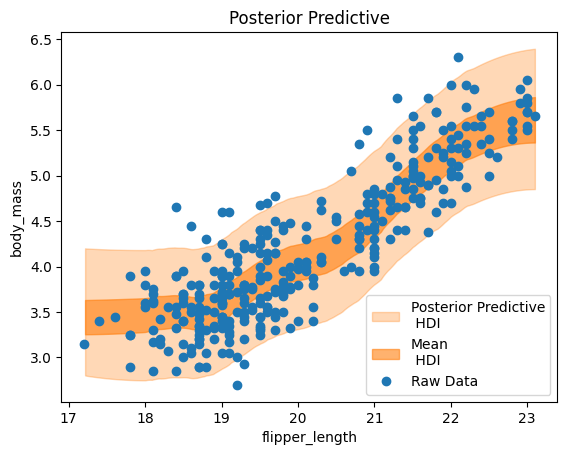

In [11]:
idx = np.argsort(X.iloc[:, 0]) # Corrected X[:, 0] to X.iloc[:, 0] for DataFrame
fig, ax = plt.subplots()

az.plot_hdi(
    x=X.iloc[:, 0], # Corrected X[:, 0] to X.iloc[:, 0] for DataFrame
    y=pps,
    ax=ax,
    hdi_prob=0.93,
    fill_kwargs={"alpha": 0.3, "label": "Posterior Predictive\n HDI"},
)

az.plot_hdi(
    x=X.iloc[:, 0], # Corrected X[:, 0] to X.iloc[:, 0] for DataFrame
    y=posterior_mean,
    ax=ax,
    hdi_prob=0.74,
    fill_kwargs={"alpha": 0.6, "label": "Mean\n HDI"},
)
ax.plot(penguinsigma["flipper_length"], penguinsigma["body_mass"], "o", c="C0", label="Raw Data")
ax.legend(loc="lower right")
ax.set(
    title="Posterior Predictive",
    xlabel="flipper_length",
    ylabel="body_mass"
);

**Task8**:

Interpret the plot above in context. Do you think it captures the true association between flipper length and body mass in penguins? Why or why not? Make sure to reference specific things you see in the plot.

Yes it does caputre the true association between flipper length and body mass for penguins. It captures the upward trend and the upward trend that flattens out.

**Task9**:

Create partial depnedence plots (pdps), individual conditional expectation (ice) plots, and a variable importance plot for the BARTpenguin model.

array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_depth'>, <Axes: xlabel='bill_length'>],
      dtype=object)

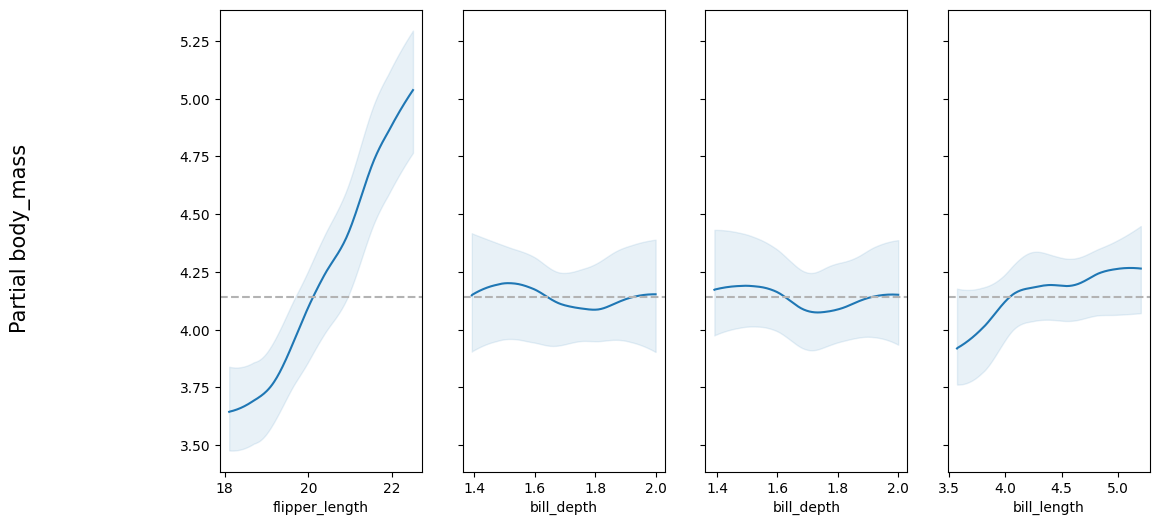

In [12]:
pmb.plot_pdp(μ_, X, Y, grid=(1, 4), func=np.exp, figsize = (12,6))


array([<Axes: xlabel='flipper_length'>, <Axes: xlabel='bill_depth'>,
       <Axes: xlabel='bill_depth'>, <Axes: xlabel='bill_length'>],
      dtype=object)

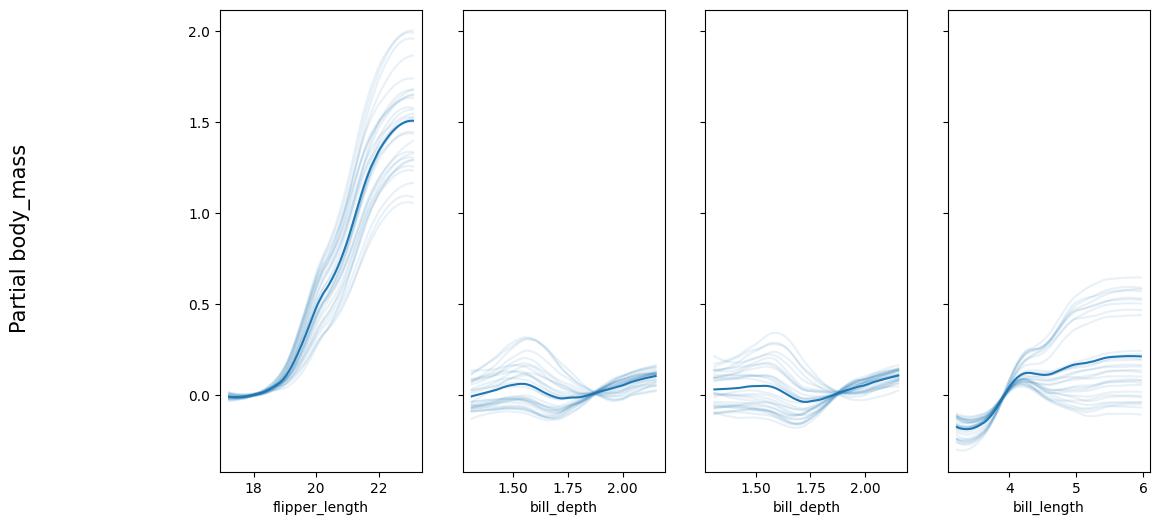

In [13]:
pmb.plot_ice( μ_, X, Y, grid=(1, 4), func=np.exp, figsize = (12,6))


<Axes: ylabel='R²'>

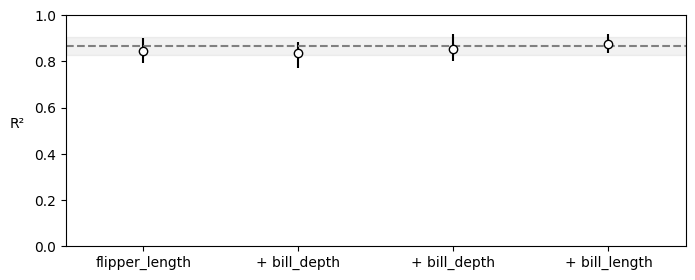

In [14]:
vi_penguins = pmb.compute_variable_importance(idata_ps, μ_, X)
pmb.plot_variable_importance(vi_penguins)

**Task10**:

Using the above plots, make an argument about which variable(s) is/are most important in predicting body mass in penguins.

What is the relationship for each variable to body mass, when you take the other variables into account?

Is that relationship complicated by interactions between variables? How do you know?

Make sure to reference specific things you see in each plot, to justify your decisions and comments.

Flipper_length is the most significant variable in predicting body mass in penguins, this is clear in the ice plots as you can see a clear linear relationship between both variables. However, it appears based on the R^2 plot that bill-length could potentially be *marginally* better as it is slightly above the flipper_length.